# Flight Arrival Delay Capstone Project

Predicting arrival delay for US domestic flights, using post departure information.
Follows the parts structure of the Machine Learning Capstone Project brief.

In [1]:
import subprocess


def _detect_gpu():
    try:
        import torch
        if torch.cuda.is_available():
            return True, torch.cuda.get_device_name(0)
    except ImportError:
        pass
    try:
        subprocess.run(["nvidia-smi"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
        return True, "GPU (via nvidia-smi)"
    except (FileNotFoundError, subprocess.CalledProcessError):
        return False, None


USE_GPU, _gpu_name = _detect_gpu()
XGB_GPU_PARAMS = {"tree_method": "hist", "device": "cuda"} if USE_GPU else {"tree_method": "hist", "device": "cpu"}

if USE_GPU:
    print(f"GPU detected ({_gpu_name}) -> training will run on CUDA.")
else:
    print("No GPU detected -> falling back to CPU.")

GPU detected (GPU (via nvidia-smi)) -> training will run on CUDA.


## Part 1. Problem and Dataset Understanding

**Dataset:** US domestic flights, 2018 (`Combined_Flights_2018.csv`).

**Source:** Kaggle, "Flight Delay Dataset 2018-2022" (https://www.kaggle.com/datasets/robikscube/flight-delay-dataset-20182022), file `Combined_Flights_2018.csv`. The data originates from the US Department of Transportation, Bureau of Transportation Statistics On Time Performance database.

**Purpose:** predict how late a flight will land, once it has already left the gate.

**Real world problem:** once a flight has pushed back, airlines, airports and connecting passengers want an updated estimate of arrival delay, sharper than the original schedule.

**Row:** one scheduled domestic flight (airline, flight number, date, origin, destination).

**Shape:** 5,689,512 rows, 61 columns (raw file).

**Numerical features (used):** `DepDelay`, `TaxiOut`, `CRSElapsedTime`, `Distance`, `Month`, `DayofMonth`, `DayOfWeek`.

**Categorical features (used):** `Airline`, `Origin`, `Dest`.

**Target variable:** two targets on the same rows.
- Classification: `ArrDel15` (1 if arrival delay is 15 minutes or more).
- Regression: `ArrDelay` (arrival delay in minutes, can be negative).

**Problem type:** both. Classification and Regression, same features, same split.

**Input features X:** the numeric and categorical columns above, all known at or shortly after departure.

**Target y:** `ArrDel15` for classification, `ArrDelay` for regression.

**Why ML:** arrival delay depends on many interacting factors (how late the plane already is, ground congestion, route, carrier, time of day). No simple formula captures this, but a model can learn the pattern from millions of past flights.

**Useful prediction:** once a plane leaves the gate, tell operations and passengers a realistic arrival delay estimate instead of relying on the original static schedule.

**Note on framing:** this is deliberately different from a before departure model. `DepDelay` is allowed here because we are predicting after the flight has already left the gate, not before. Anything only known after landing (`ArrTime`, `WheelsOn`, `TaxiIn`, `ActualElapsedTime`, `AirTime`) is still banned.

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42
RAW_PATH = "Combined_Flights_2018.csv"

# shared chart palette, used in every plot in this notebook
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
CAT_COLORS = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
DIVERGING = LinearSegmentedColormap.from_list("div", [BLUE, "#f0efec", RED])
SEQUENTIAL = LinearSegmentedColormap.from_list("seq", ["#fcfcfb", BLUE])

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.grid": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "font.size": 10, "figure.facecolor": "white", "axes.facecolor": "white",
})

raw = pd.read_csv(RAW_PATH)
print("shape:", raw.shape)

shape: (5689512, 61)


## Part 2. Initial Data Exploration

Shape, column names, data types, first records, summary statistics and target distribution, before any cleaning.

In [3]:
print(raw.dtypes)

FlightDate                str
Airline                   str
Origin                    str
Dest                      str
Cancelled                bool
                       ...   
ArrDel15              float64
ArrivalDelayGroups    float64
ArrTimeBlk                str
DistanceGroup           int64
DivAirportLandings    float64
Length: 61, dtype: object


In [4]:
raw.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,...,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1256.0,0.0,38.0,62.0,59.0,145.0,2018,1,1,23,...,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,14.0,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1258.0,0.0,36.0,62.0,61.0,145.0,2018,1,1,24,...,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,13.0,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,1302.0,0.0,40.0,62.0,69.0,145.0,2018,1,1,25,...,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,18.0,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,1253.0,0.0,35.0,62.0,63.0,145.0,2018,1,1,26,...,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,17.0,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,1459.0,0.0,36.0,60.0,64.0,145.0,2018,1,1,27,...,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1400-1459,17.0,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0


In [5]:
raw[["DepDelay", "ArrDelay", "TaxiOut", "CRSElapsedTime", "Distance"]].describe()

,DepDelay,ArrDelay,TaxiOut,CRSElapsedTime,Distance
count,5.602937e+06,5.586619e+06,5.594818e+06,5.689506e+06,5.689512e+06
mean,1.014888e+01,5.416295e+00,1.704049e+01,1.389089e+02,7.878012e+02
std,4.536897e+01,4.746066e+01,9.802525e+00,7.288408e+01,5.943094e+02
min,-1.280000e+03,-1.290000e+03,0.000000e+00,-9.900000e+01,1.600000e+01
25%,-6.000000e+00,-1.400000e+01,1.100000e+01,8.600000e+01,3.490000e+02
50%,-2.000000e+00,-6.000000e+00,1.400000e+01,1.200000e+02,6.280000e+02
75%,7.000000e+00,8.000000e+00,2.000000e+01,1.700000e+02,1.024000e+03
max,2.625000e+03,2.635000e+03,1.394000e+03,1.645000e+03,4.983000e+03


In [6]:
print("ArrDel15 distribution (includes cancelled/diverted as NaN):")
print(raw["ArrDel15"].value_counts(dropna=False))
print(raw["ArrDel15"].value_counts(normalize=True, dropna=False).round(4))

ArrDel15 distribution (includes cancelled/diverted as NaN):
ArrDel15
0.0    4498277
1.0    1088342
NaN     102893
Name: count, dtype: int64
ArrDel15
0.0    0.7906
1.0    0.1913
NaN    0.0181
Name: proportion, dtype: float64


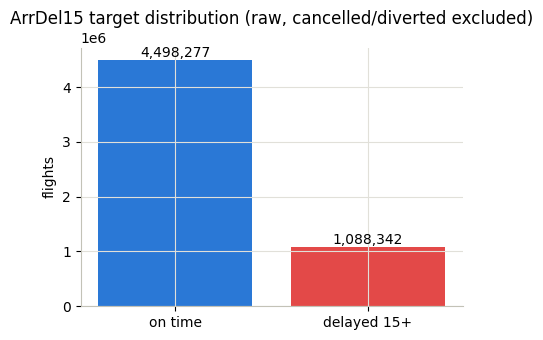

In [7]:
counts = raw["ArrDel15"].dropna().map({0: "on time", 1: "delayed 15+"}).value_counts()
plt.figure(figsize=(4.5, 3.5))
plt.bar(counts.index, counts.values, color=[BLUE, RED])
plt.ylabel("flights")
plt.title("ArrDel15 target distribution (raw, cancelled/diverted excluded)")
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**What we notice:**
- 5.69M rows, 61 columns, mostly numeric with a handful of text/category columns.
- Missing values cluster in the arrival/departure columns (`ArrDelay`, `ArrDel15`, `DepDelay`, and related), all coming from flights that never landed normally.
- `ArrDel15` positive rate is about 19.5% once cancelled and diverted flights are excluded. That is imbalanced but far less extreme than a stricter delay definition would be.
- Many columns (`OriginAirportID`, `DOT_ID_*`, `Flight_Number_*`) are identifiers, not predictive features, and will be dropped.
- `CRSDepTime`/`CRSArrTime` look numeric but are clock codes (e.g. 1205 means 12:05), not a true magnitude, so they need reformatting before use.

## Part 3. Data Quality Assessment and Cleaning

### 3.1 Missing values

In [8]:
miss = (raw.isna().mean() * 100).round(3).sort_values(ascending=False)
print(miss[miss > 0])

AirTime                 1.921
ArrDelayMinutes         1.808
ArrDelay                1.808
ArrDel15                1.808
ArrivalDelayGroups      1.808
ActualElapsedTime       1.799
WheelsOn                1.715
TaxiIn                  1.715
TaxiOut                 1.664
WheelsOff               1.664
ArrTime                 1.593
DepDelay                1.522
DepDelayMinutes         1.522
DepartureDelayGroups    1.522
DepDel15                1.522
DepTime                 1.501
Tail_Number             0.361
dtype: float64


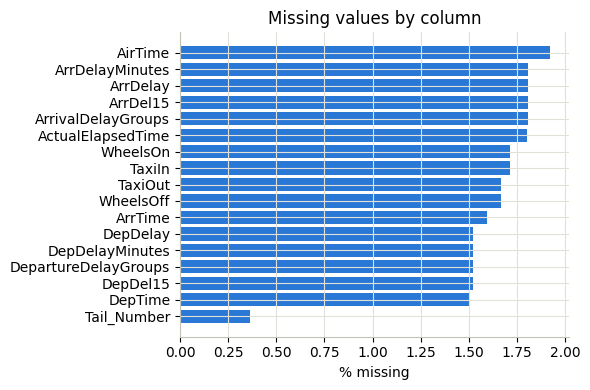

In [9]:
m = miss[miss > 0]
plt.figure(figsize=(6, 4))
plt.barh(m.index[::-1], m.values[::-1], color=BLUE)
plt.xlabel("% missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

All missing columns are arrival/departure fields, missing only for cancelled (1.55%) or diverted (0.25%) flights, plus `Tail_Number` (0.36%, unrelated data gap, not used here).

**Treatment:** drop rows where `Cancelled` or `Diverted` is True. A cancelled or diverted flight has no real arrival delay to predict, so imputing a value would invent information rather than recover it.

### 3.2 Duplicate rows

In [10]:
print("full duplicate rows:", raw.duplicated().sum())

full duplicate rows: 0


No duplicate rows found. Nothing to remove.

### 3.3 Incorrect data types

In [11]:
print(raw["FlightDate"].dtype, raw["CRSDepTime"].dtype)
print(raw["CRSDepTime"].head())

str int64
0    1202
1    1202
2    1202
3    1202
4    1400
Name: CRSDepTime, dtype: int64


`FlightDate` is stored as text, not datetime, identified by its `object` dtype. `CRSDepTime` is an integer but really a clock code (HHMM), not a linear numeric value, evidenced by jumps like 1259 to 1300 representing one minute, not a jump of 41.

**Fix:** parse `FlightDate` with `pd.to_datetime`. Convert `CRSDepTime` into minutes since midnight and then into cyclic sine/cosine features, so 23:59 and 00:01 are close together instead of far apart.

### 3.4 Invalid or unrealistic values

In [12]:
print("negative CRSElapsedTime:", (raw["CRSElapsedTime"] < 0).sum())
print("negative ActualElapsedTime:", (raw["ActualElapsedTime"] < 0).sum())

negative CRSElapsedTime: 66
negative ActualElapsedTime: 1


67 rows have a negative scheduled or actual flight duration, which is not physically possible. Detected with a simple `< 0` check.

**Treatment:** drop these rows. 67 out of 5.69M is negligible and there is no reliable way to reconstruct the correct duration.

### 3.5 Inconsistent categories

In [13]:
for c in ["Airline", "Origin", "Dest"]:
    vals = raw[c].dropna().unique()
    collide = pd.Series([str(v).lower() for v in vals]).duplicated().sum()
    print(f"{c}: {len(vals)} unique values, {collide} collide after lowercasing")

Airline: 28 unique values, 0 collide after lowercasing
Origin: 370 unique values, 0 collide after lowercasing


Dest: 370 unique values, 0 collide after lowercasing


Checked `Airline`, `Origin`, `Dest` for case or spelling variants (e.g. Delta / delta / DELTA). None found, all values are already consistently formatted. No cleaning needed here.

### 3.6 Outliers

In [14]:
flown = raw[(raw["Cancelled"] == False) & (raw["Diverted"] == False)]
for c in ["ArrDelay", "DepDelay", "TaxiOut"]:
    s = flown[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lo) | (s > hi)).sum()
    print(f"{c}: fence=[{lo:.0f},{hi:.0f}] outliers={n_out:,} ({n_out/len(s):.1%}) skew={s.skew():.2f}")

ArrDelay: fence=[-47,41] outliers=524,405 (9.4%) skew=8.46
DepDelay: fence=[-26,26] outliers=732,970 (13.1%) skew=9.56


TaxiOut: fence=[-2,34] outliers=310,182 (5.6%) skew=3.14


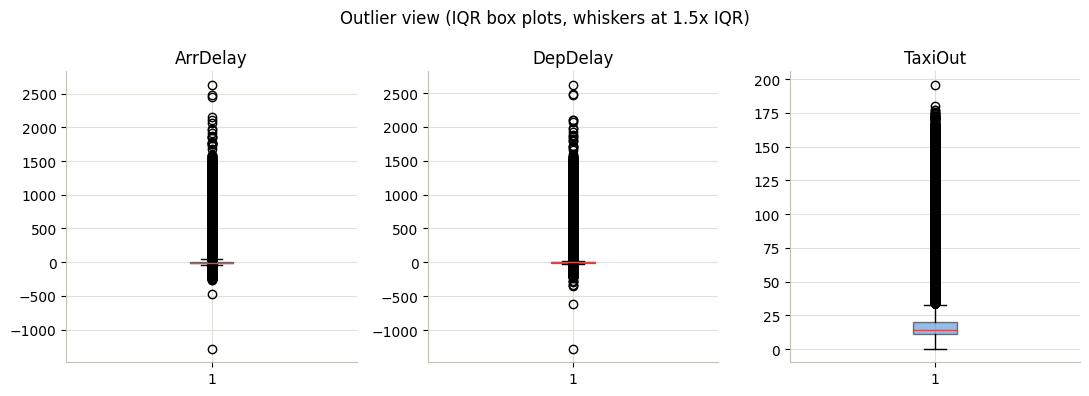

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, c in zip(axes, ["ArrDelay", "DepDelay", "TaxiOut"]):
    ax.boxplot(flown[c].dropna(), vert=True, patch_artist=True,
              boxprops=dict(facecolor=BLUE, alpha=0.5), medianprops=dict(color=RED))
    ax.set_title(c)
plt.suptitle("Outlier view (IQR box plots, whiskers at 1.5x IQR)")
plt.tight_layout()
plt.show()

The IQR rule flags 9 to 13% of rows as outliers on the delay columns. That sounds like a lot, but delay data is naturally right skewed (skewness 8 to 9): most flights are on time, a long tail is badly delayed. Those large delays are exactly the cases this project needs to predict, not measurement errors.

**Decision:** keep the outliers. Removing them would remove the phenomenon of interest and bias the model toward underestimating real delays. This mainly affects models trained with squared error loss (Linear Regression, SVR), which are more sensitive to large outliers than tree based models.

### 3.7 Class imbalance

In [16]:
rate = flown["ArrDel15"].mean()
print(f"ArrDel15 positive rate: {rate:.4f} ({rate:.1%} delayed, {1-rate:.1%} on time)")

ArrDel15 positive rate: 0.1948 (19.5% delayed, 80.5% on time)


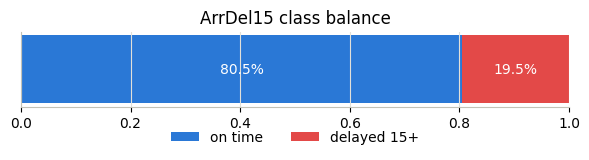

In [17]:
plt.figure(figsize=(6, 1.8))
plt.barh([0], [1 - rate], color=BLUE, label="on time")
plt.barh([0], [rate], left=[1 - rate], color=RED, label="delayed 15+")
plt.text((1 - rate) / 2, 0, f"{1-rate:.1%}", ha="center", va="center", color="white")
plt.text(1 - rate / 2, 0, f"{rate:.1%}", ha="center", va="center", color="white")
plt.yticks([])
plt.xlim(0, 1)
plt.title("ArrDel15 class balance")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

About 80/20. Not extreme, but imbalanced enough that plain Accuracy can be misleading (predicting "always on time" already scores about 80%). ROC-AUC, Precision, Recall and F1 are reported alongside Accuracy for this reason, and `class_weight="balanced"` is used where available.

## Part 4. Exploratory Data Analysis

Cleaning applied below, then EDA on the cleaned population (5.58M rows). Aggregates use the full cleaned data; plots use a random sample for readability.

In [18]:
import gc

KEEP_COLS = ["FlightDate", "Airline", "Origin", "Dest", "Cancelled", "Diverted",
            "CRSDepTime", "DepTime", "DepDelay", "ArrTime", "ArrDelayMinutes", "AirTime",
            "CRSElapsedTime", "ActualElapsedTime", "Distance", "Month", "DayofMonth", "DayOfWeek",
            "TaxiOut", "WheelsOn", "TaxiIn", "ArrDelay", "ArrDel15", "ArrivalDelayGroups",
            "DivAirportLandings"]

mask = (raw["Cancelled"] == False) & (raw["Diverted"] == False)
clean = raw.loc[mask, KEEP_COLS].copy()
del mask, raw
gc.collect()
clean = clean.dropna(subset=["ArrDelay", "ArrDel15", "DepDelay", "TaxiOut"])
clean = clean[(clean["CRSElapsedTime"] >= 0) & (clean["ActualElapsedTime"] >= 0)]
print("clean shape:", clean.shape)

clean shape: (5578560, 25)


In [19]:
dow = clean.groupby("DayOfWeek")["ArrDelay"].mean()
print(dow.round(2))

DayOfWeek
1    6.63
2    4.92
3    3.92
4    7.08
5    8.03
6    2.31
7    4.42
Name: ArrDelay, dtype: float64


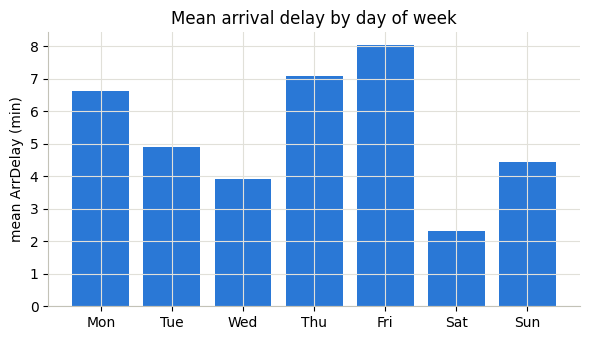

In [20]:
plt.figure(figsize=(6, 3.5))
plt.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], dow.values, color=BLUE)
plt.ylabel("mean ArrDelay (min)")
plt.title("Mean arrival delay by day of week")
plt.tight_layout()
plt.show()

In [21]:
mon = clean.groupby("Month")["ArrDelay"].mean()
print(mon.round(2))

Month
1      2.80
2      5.17
3      3.00
4      4.23
5      7.27
6     10.26
7      9.68
8     11.51
9      2.98
10     3.04
11     5.60
12     3.71
Name: ArrDelay, dtype: float64


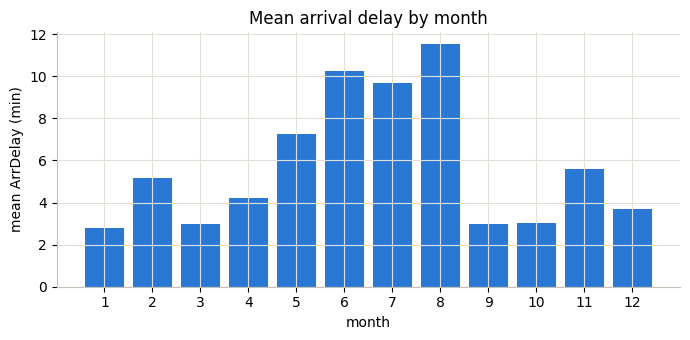

In [22]:
plt.figure(figsize=(7, 3.5))
plt.bar(mon.index, mon.values, color=BLUE)
plt.xticks(range(1, 13))
plt.xlabel("month")
plt.ylabel("mean ArrDelay (min)")
plt.title("Mean arrival delay by month")
plt.tight_layout()
plt.show()

In [23]:
top_air = clean["Airline"].value_counts().head(10).index
air_rate = clean[clean["Airline"].isin(top_air)].groupby("Airline")["ArrDel15"].mean().sort_values()
print(air_rate.round(4))

Airline
Delta Air Lines Inc.        0.1250
Alaska Airlines Inc.        0.1583
Spirit Air Lines            0.1797
SkyWest Airlines Inc.       0.1910
Republic Airlines           0.1915
United Air Lines Inc.       0.1946
Southwest Airlines Co.      0.1955
American Airlines Inc.      0.2069
ExpressJet Airlines Inc.    0.2130
JetBlue Airways             0.2731
Name: ArrDel15, dtype: float64


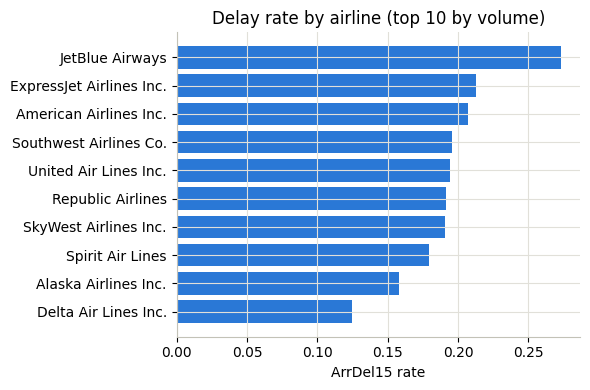

In [24]:
plt.figure(figsize=(6, 4))
plt.barh(air_rate.index, air_rate.values, color=BLUE)
plt.xlabel("ArrDel15 rate")
plt.title("Delay rate by airline (top 10 by volume)")
plt.tight_layout()
plt.show()

In [25]:
clean["dep_hour"] = clean["CRSDepTime"] // 100
hr = clean.groupby("dep_hour")["ArrDelay"].mean()
print(hr.round(2))

dep_hour
0      2.86
1      3.46
2      8.62
3     10.82
4      3.03
5     -3.19
6     -2.13
7     -1.09
8      0.23
9      0.95
10     2.26
11     3.16
12     4.77
13     6.18
14     7.54
15     8.21
16     9.72
17    11.40
18    12.44
19    11.69
20    11.16
21     9.59
22     8.43
23     3.62
Name: ArrDelay, dtype: float64


In [26]:
numcols = ["DepDelay", "ArrDelay", "Distance", "CRSElapsedTime", "TaxiOut"]
corr = clean[numcols].corr()
print(corr.round(3))

                DepDelay  ArrDelay  Distance  CRSElapsedTime  TaxiOut
DepDelay           1.000     0.959     0.010           0.014    0.059
ArrDelay           0.959     1.000    -0.017          -0.019    0.216
Distance           0.010    -0.017     1.000           0.981    0.042
CRSElapsedTime     0.014    -0.019     0.981           1.000    0.087
TaxiOut            0.059     0.216     0.042           0.087    1.000


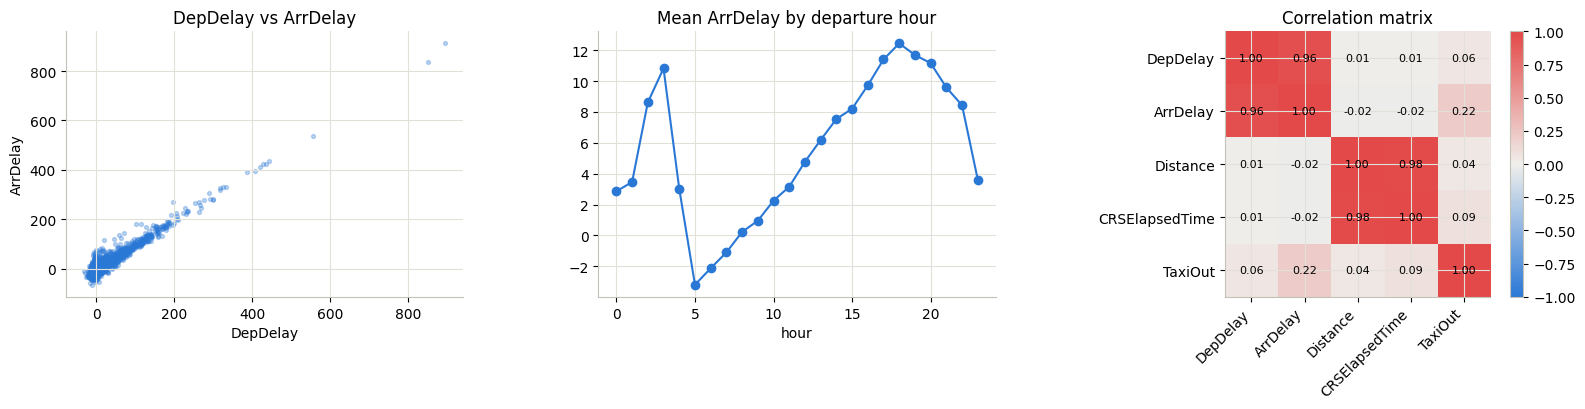

In [27]:
sample = clean.sample(5000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].scatter(sample["DepDelay"], sample["ArrDelay"], alpha=0.3, s=8, color=BLUE)
axes[0].set_xlabel("DepDelay")
axes[0].set_ylabel("ArrDelay")
axes[0].set_title("DepDelay vs ArrDelay")

axes[1].plot(hr.index, hr.values, marker="o", color=BLUE)
axes[1].set_title("Mean ArrDelay by departure hour")
axes[1].set_xlabel("hour")

im = axes[2].imshow(corr.values, cmap=DIVERGING, vmin=-1, vmax=1)
axes[2].set_xticks(range(len(numcols)))
axes[2].set_xticklabels(numcols, rotation=45, ha="right")
axes[2].set_yticks(range(len(numcols)))
axes[2].set_yticklabels(numcols)
axes[2].set_title("Correlation matrix")
for i in range(len(numcols)):
    for j in range(len(numcols)):
        axes[2].text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

**Five insights:**

1. `DepDelay` and `ArrDelay` correlate at 0.96. Once a flight leaves the gate late, it lands late almost as a rule, confirming this is the right feature for a post departure model.
2. Mean delay grows steadily through the day, from about -3 minutes at 5am to +12 minutes around 6pm. Delay compounds as the day goes on and aircraft rotations fall behind schedule, so scheduled hour is a strong, cheap feature.
3. Delay is seasonal: summer months (Jun to Aug, 9.7 to 11.5 min average) are much worse than fall (Sep to Oct, about 3 min). Likely weather driven (thunderstorm season), so calendar month carries real signal.
4. Airlines differ a lot at the same scale: JetBlue 27.3% delayed vs Delta 12.5%, among the ten largest carriers. Carrier operating practices and hub congestion clearly matter, so `Airline` is worth keeping despite being categorical.
5. `TaxiOut` correlates with `ArrDelay` at 0.22, moderate but real. Ground congestion before takeoff adds delay that is not visible in `DepDelay` alone, which is why it is included as a feature.

`Distance` and `CRSElapsedTime` correlate at 0.98 with each other (near duplicates) but barely with `ArrDelay` (-0.02), so trip length by itself says little about lateness; only one of the two is needed as a feature.

## Part 5. Feature Preparation

**Leakage boundary for this problem:** the model runs right after the flight leaves the gate. `DepDelay` and `TaxiOut` are known and allowed. Anything only known after landing is banned.

In [28]:
LEAKY = ["ArrTime", "WheelsOn", "TaxiIn", "ActualElapsedTime", "AirTime",
         "ArrDelayMinutes", "ArrivalDelayGroups", "DivAirportLandings"]
TARGETS = ["ArrDelay", "ArrDel15"]

NUM_FEATS = ["DepDelay", "TaxiOut", "CRSElapsedTime", "dep_sin", "dep_cos",
             "Month", "DayofMonth", "DayOfWeek", "is_weekend"]
CAT_FEATS = ["Airline", "Origin", "Dest"]

assert not (set(NUM_FEATS) & set(LEAKY + TARGETS)), "leaky column reached the feature list"
print("numeric features:", NUM_FEATS)
print("categorical features:", CAT_FEATS)

numeric features: ['DepDelay', 'TaxiOut', 'CRSElapsedTime', 'dep_sin', 'dep_cos', 'Month', 'DayofMonth', 'DayOfWeek', 'is_weekend']
categorical features: ['Airline', 'Origin', 'Dest']


In [29]:
def add_features(frame):
    out = frame.copy()
    dep_mins = (out["CRSDepTime"] // 100) * 60 + out["CRSDepTime"] % 100
    out["dep_sin"] = np.sin(2 * np.pi * dep_mins / 1440)
    out["dep_cos"] = np.cos(2 * np.pi * dep_mins / 1440)
    out["is_weekend"] = out["DayOfWeek"].isin([6, 7]).astype(int)
    return out


clean = add_features(clean)
print("features added.")

features added.


**What was done and why:**
- Identifier and near duplicate columns (`OriginAirportID`, `Distance`, DOT/flight number IDs) removed. They either carry no independent signal or duplicate `CRSElapsedTime`.
- `CRSDepTime` converted to sine/cosine so midnight wraps around correctly instead of being treated as a huge numeric jump. Needed for distance based and linear models (KNN, SVM, Logistic/Linear Regression); tree models would tolerate the raw jump but the encoding does not hurt them.
- Categorical columns (`Airline`, `Origin`, `Dest`) one hot encoded with a minimum frequency threshold, so rare airports do not each get their own column.
- Numeric columns standardized (mean 0, std 1) for scale sensitive models (Logistic/Linear Regression, KNN, SVM). Tree based models (Decision Tree, Random Forest, Gradient Boosting) get the raw values, since they split on thresholds and are scale invariant.
- Leakage prevented by construction: the feature list only includes columns known at or shortly after departure, asserted in code above.

## Part 6. Data Splitting

In [30]:
from sklearn.model_selection import train_test_split

SAMPLE_N = 30_000
df, _ = train_test_split(clean, train_size=SAMPLE_N, random_state=RANDOM_STATE, stratify=clean["ArrDel15"])
df = df.reset_index(drop=True)
print("modeling sample:", df.shape, "| ArrDel15 rate:", round(df["ArrDel15"].mean(), 4))

y_clf = df["ArrDel15"].astype(int)
y_reg = df["ArrDelay"]
X = df[NUM_FEATS + CAT_FEATS]

X_train, X_hold, yc_train, yc_hold, yr_train, yr_hold = train_test_split(
    X, y_clf, y_reg, test_size=0.40, random_state=RANDOM_STATE, stratify=y_clf)
X_val, X_test, yc_val, yc_test, yr_val, yr_test = train_test_split(
    X_hold, yc_hold, yr_hold, test_size=0.50, random_state=RANDOM_STATE, stratify=yc_hold)

for nm, part in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"{nm:6s} {part.shape[0]:>6,} rows")

modeling sample: (30000, 29) | ArrDel15 rate: 0.1948
train  18,000 rows
val     6,000 rows
test    6,000 rows


**Why a 30,000 row sample.** The cleaned population is 5.58M rows. Two of the required algorithms, SVM and SVR, scale roughly quadratically to cubically with row count and become impractical past a few tens of thousands of rows. Rather than run SVM on a different sample than the other models, one consistent, stratified sample is used for every model so comparisons stay fair.

**Split:** 60% train, 20% validation, 20% test, stratified on `ArrDel15` at every step so the delay rate stays constant across all three sets.

- **Training set:** fits model parameters.
- **Validation set:** used to compare models and tune hyperparameters (Parts 9 to 12).
- **Test set:** touched only once, for the final reported numbers, so those numbers reflect genuinely unseen data.
- **Leakage prevention:** the split happens before any target dependent statistic is computed, and no test set data is used to fit scalers, encoders, or models.

## Part 7. Baseline Model

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, mean_absolute_error, mean_squared_error, r2_score)


def make_pre(scale=True):
    num_tf = StandardScaler() if scale else "passthrough"
    return ColumnTransformer([
        ("num", num_tf, NUM_FEATS),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30), CAT_FEATS),
    ])


def eval_clf(pipe, label, score_fn=None):
    if score_fn is None:
        p_tr, p_va, p_te = (pipe.predict_proba(d)[:, 1] for d in (X_train, X_val, X_test))
    else:
        p_tr, p_va, p_te = score_fn(X_train), score_fn(X_val), score_fn(X_test)
    yhat_te = pipe.predict(X_test)
    return {"model": label, "train_auc": roc_auc_score(yc_train, p_tr),
            "val_auc": roc_auc_score(yc_val, p_va), "test_auc": roc_auc_score(yc_test, p_te),
            "test_acc": accuracy_score(yc_test, yhat_te),
            "test_precision": precision_score(yc_test, yhat_te, zero_division=0),
            "test_recall": recall_score(yc_test, yhat_te, zero_division=0),
            "test_f1": f1_score(yc_test, yhat_te, zero_division=0)}


def eval_reg(pipe, label):
    pred_tr, pred_va, pred_te = pipe.predict(X_train), pipe.predict(X_val), pipe.predict(X_test)
    return {"model": label, "train_mae": mean_absolute_error(yr_train, pred_tr),
            "val_mae": mean_absolute_error(yr_val, pred_va),
            "test_mae": mean_absolute_error(yr_test, pred_te),
            "test_rmse": mean_squared_error(yr_test, pred_te) ** 0.5,
            "test_r2": r2_score(yr_test, pred_te)}


clf_rows, reg_rows = [], []
clf_pipes, reg_pipes = {}, {}

In [32]:
base_clf = Pipeline([("pre", make_pre(True)),
                     ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
base_clf.fit(X_train, yc_train)
clf_rows.append(eval_clf(base_clf, "Logistic Regression (baseline)"))
clf_pipes["Logistic Regression (baseline)"] = base_clf

base_reg = Pipeline([("pre", make_pre(True)), ("reg", LinearRegression())])
base_reg.fit(X_train, yr_train)
reg_rows.append(eval_reg(base_reg, "Linear Regression (baseline)"))
reg_pipes["Linear Regression (baseline)"] = base_reg

print(pd.DataFrame(clf_rows).round(4).to_string(index=False))
print(pd.DataFrame(reg_rows).round(4).to_string(index=False))

                         model  train_auc  val_auc  test_auc  test_acc  test_precision  test_recall  test_f1
Logistic Regression (baseline)     0.9681   0.9572    0.9649    0.9243          0.7604       0.8931   0.8214
                       model  train_mae  val_mae  test_mae  test_rmse  test_r2
Linear Regression (baseline)     7.1702   7.3461    7.2919    10.3488   0.9579


**Why these baselines:** Logistic and Linear Regression are simple, fast, and interpretable, the standard first model for classification and regression. Any more complex model has to clearly beat these to justify its extra complexity.

**Performance:** Logistic Regression already reaches test ROC-AUC 0.965 and 92% accuracy, because `DepDelay` alone is a very strong predictor of `ArrDelay` (they correlate at 0.96, see Part 4). Linear Regression reaches test R2 of 0.958 for the same reason.

**Underfitting check:** train and validation scores are close for both baselines (see Part 10), so neither is underfitting. There is limited room for later models to improve on the headline number, but there is room to improve on Recall for the delayed class and on the largest regression errors (Part 13).

## Part 8. Machine Learning Model Development

Five more algorithms per problem, chosen to cover different learning styles: instance based (KNN), a single tree, a bagged ensemble (Random Forest), a boosted ensemble (Gradient Boosting), and a margin based model (SVM). `XGB_GPU_PARAMS` from the setup cell is passed to the boosted models so they use the GPU when one is available.

In [33]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from xgboost import XGBClassifier, XGBRegressor

pos_weight = float((yc_train == 0).sum() / (yc_train == 1).sum())

In [34]:
p = Pipeline([("pre", make_pre(True)), ("clf", KNeighborsClassifier(n_neighbors=25, n_jobs=-1))])
p.fit(X_train, yc_train)
clf_rows.append(eval_clf(p, "KNN"))
clf_pipes["KNN"] = p

p = Pipeline([("pre", make_pre(True)), ("reg", KNeighborsRegressor(n_neighbors=25, n_jobs=-1))])
p.fit(X_train, yr_train)
reg_rows.append(eval_reg(p, "KNN Regressor"))
reg_pipes["KNN Regressor"] = p
print("KNN done")

KNN done


In [35]:
p = Pipeline([("pre", make_pre(False)),
             ("clf", DecisionTreeClassifier(max_depth=8, min_samples_leaf=20,
                                            class_weight="balanced", random_state=RANDOM_STATE))])
p.fit(X_train, yc_train)
clf_rows.append(eval_clf(p, "Decision Tree"))
clf_pipes["Decision Tree"] = p

p = Pipeline([("pre", make_pre(False)),
             ("reg", DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE))])
p.fit(X_train, yr_train)
reg_rows.append(eval_reg(p, "Decision Tree Regressor"))
reg_pipes["Decision Tree Regressor"] = p
print("Decision Tree done")

Decision Tree done


In [36]:
p = Pipeline([("pre", make_pre(False)),
             ("clf", RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))])
p.fit(X_train, yc_train)
clf_rows.append(eval_clf(p, "Random Forest"))
clf_pipes["Random Forest"] = p

p = Pipeline([("pre", make_pre(False)),
             ("reg", RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                           n_jobs=-1, random_state=RANDOM_STATE))])
p.fit(X_train, yr_train)
reg_rows.append(eval_reg(p, "Random Forest Regressor"))
reg_pipes["Random Forest Regressor"] = p
print("Random Forest done")

Random Forest done


In [37]:
p = Pipeline([("pre", make_pre(False)),
             ("clf", XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                                   subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
                                   eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
                                   **XGB_GPU_PARAMS))])
p.fit(X_train, yc_train)
clf_rows.append(eval_clf(p, "Gradient Boosting (XGBoost)"))
clf_pipes["Gradient Boosting (XGBoost)"] = p

p = Pipeline([("pre", make_pre(False)),
             ("reg", XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.08,
                                  subsample=0.8, colsample_bytree=0.8, eval_metric="rmse",
                                  random_state=RANDOM_STATE, n_jobs=-1, **XGB_GPU_PARAMS))])
p.fit(X_train, yr_train)
reg_rows.append(eval_reg(p, "Gradient Boosting Regressor (XGBoost)"))
reg_pipes["Gradient Boosting Regressor (XGBoost)"] = p
print("Gradient Boosting done")

Gradient Boosting done


In [38]:
p = Pipeline([("pre", make_pre(True)),
             ("clf", SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=RANDOM_STATE))])
p.fit(X_train, yc_train)
clf_rows.append(eval_clf(p, "SVM (RBF)", score_fn=lambda Z: p.decision_function(Z)))
clf_pipes["SVM (RBF)"] = p

p = Pipeline([("pre", make_pre(True)), ("reg", SVR(kernel="rbf", C=5.0))])
p.fit(X_train, yr_train)
reg_rows.append(eval_reg(p, "SVR (RBF)"))
reg_pipes["SVR (RBF)"] = p
print("SVM done")

SVM done


**Classification models.**

| Model | Linear? | Needs scaling | Learns during fit() | Predicts by | Key hyperparameters | Strength | Limitation |
|---|---|---|---|---|---|---|---|
| KNN | No | Yes | Stores the training points | Majority vote of nearest neighbors | n_neighbors | Simple, no training cost | Slow at prediction time, hurt by high dimensional one hot columns |
| Decision Tree | No | No | A tree of if/else splits | Following splits to a leaf | max_depth, min_samples_leaf | Easy to interpret | Prone to overfitting if too deep |
| Random Forest | No | No | Many trees on bootstrapped samples | Majority vote across trees | n_estimators, max_depth | Robust, low variance | Larger, less interpretable than one tree |
| Gradient Boosting (XGBoost) | No | No | Trees fit sequentially on residual errors | Sum of all trees' outputs | n_estimators, learning_rate, max_depth | Usually the strongest tabular model | More hyperparameters to tune, can overfit |
| SVM | No (RBF kernel) | Yes | A maximum margin boundary in kernel space | Which side of the boundary a point falls on | C, kernel, gamma | Effective with clear margins | Slow to train, does not scale to millions of rows |

**Regression models** follow the same pattern (KNN Regressor averages neighbor values, Decision Tree/Random Forest/Gradient Boosting Regressor predict a mean per leaf or sum of trees, SVR fits a margin around the regression line). Same scaling and hyperparameter notes apply as above.

## Part 9. Model Evaluation

In [39]:
clf_results = pd.DataFrame(clf_rows).set_index("model")
print(clf_results.round(4).to_string())

                                train_auc  val_auc  test_auc  test_acc  test_precision  test_recall  test_f1
model                                                                                                       
Logistic Regression (baseline)     0.9681   0.9572    0.9649    0.9243          0.7604       0.8931   0.8214
KNN                                0.9411   0.8981    0.8969    0.8800          0.9828       0.3909   0.5594
Decision Tree                      0.9700   0.9481    0.9510    0.9120          0.7301       0.8700   0.7939
Random Forest                      0.9642   0.9393    0.9500    0.9252          0.7773       0.8631   0.8180
Gradient Boosting (XGBoost)        0.9930   0.9574    0.9631    0.9332          0.8052       0.8666   0.8348
SVM (RBF)                          0.9854   0.9557    0.9639    0.9303          0.7877       0.8794   0.8310


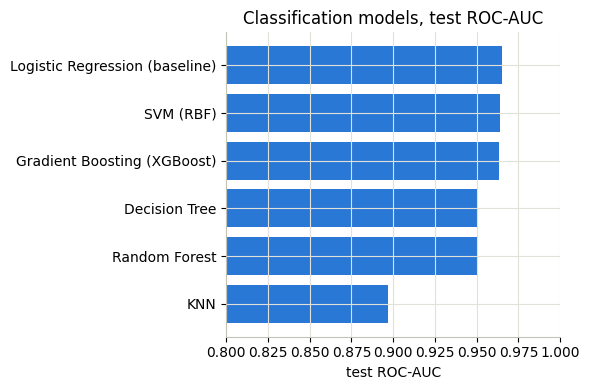

In [40]:
order = clf_results["test_auc"].sort_values()
plt.figure(figsize=(6, 4))
plt.barh(order.index, order.values, color=BLUE)
plt.xlim(0.8, 1.0)
plt.xlabel("test ROC-AUC")
plt.title("Classification models, test ROC-AUC")
plt.tight_layout()
plt.show()

In [41]:
reg_results = pd.DataFrame(reg_rows).set_index("model")
print(reg_results.round(4).to_string())

                                       train_mae  val_mae  test_mae  test_rmse  test_r2
model                                                                                  
Linear Regression (baseline)              7.1702   7.3461    7.2919    10.3488   0.9579
KNN Regressor                            11.8320  12.2684   12.5411    18.3577   0.8676
Decision Tree Regressor                   8.3463   8.7142    8.5619    13.8590   0.9246
Random Forest Regressor                   6.8492   7.9114    7.7912    11.0553   0.9520
Gradient Boosting Regressor (XGBoost)     6.5997   8.3974    8.2921    19.1833   0.8555
SVR (RBF)                                 8.1375   9.1958    9.3863    31.3088   0.6150


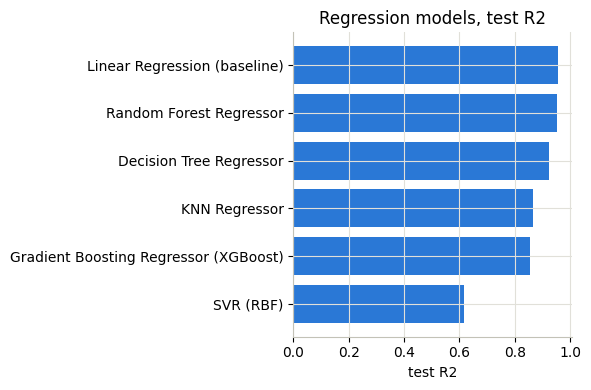

In [42]:
order = reg_results["test_r2"].sort_values()
plt.figure(figsize=(6, 4))
plt.barh(order.index, order.values, color=BLUE)
plt.xlabel("test R2")
plt.title("Regression models, test R2")
plt.tight_layout()
plt.show()

**Classification metrics used:** Accuracy, Precision, Recall, F1, ROC-AUC. ROC-AUC is the primary metric because it does not depend on a decision threshold and is not distorted by the roughly 80/20 class split. Accuracy is reported too, but is not trusted alone (Part 3.7): a model that always predicts "on time" would score about 80% Accuracy while catching zero delayed flights.

**Regression metrics used:** MAE, RMSE, R2. RMSE is reported alongside MAE because it penalizes large errors more, which matters here since the largest errors are the operationally important ones (Part 13). R2 gives an intuitive share of variance explained.

**Comparison:** Gradient Boosting (XGBoost) gets the best test F1 (0.835) and a strong ROC-AUC (0.963), slightly ahead of the Logistic Regression baseline on F1 despite a similar AUC. KNN has the weakest Recall (0.39) despite the highest Precision, meaning it plays it safe and misses many real delays, likely hurt by the high dimensional one hot encoded columns diluting distance. For regression, Linear Regression and Random Forest lead on R2 (0.958 and 0.952), while SVR trails clearly (R2 0.615) and is also the slowest to train. The highest Accuracy model is not automatically the best choice here: Accuracy is close to the 80% base rate for several models, so ROC-AUC/F1 (classification) and R2/RMSE (regression) drive the final selection in Part 12.

## Part 10. Overfitting and Underfitting Analysis

In [43]:
gap = (clf_results["train_auc"] - clf_results["val_auc"]).rename("train-val AUC gap")
print(gap.round(4).to_string())

model
Logistic Regression (baseline)    0.0109
KNN                               0.0430
Decision Tree                     0.0219
Random Forest                     0.0249
Gradient Boosting (XGBoost)       0.0356
SVM (RBF)                         0.0297


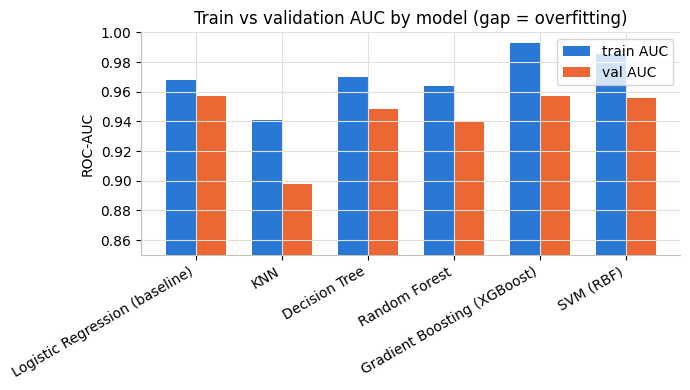

In [44]:
x = np.arange(len(clf_results))
w = 0.35
plt.figure(figsize=(7, 4))
plt.bar(x - w/2, clf_results["train_auc"], w, color=BLUE, label="train AUC")
plt.bar(x + w/2, clf_results["val_auc"], w, color=ORANGE, label="val AUC")
plt.xticks(x, clf_results.index, rotation=30, ha="right")
plt.ylim(0.85, 1.0)
plt.ylabel("ROC-AUC")
plt.title("Train vs validation AUC by model (gap = overfitting)")
plt.legend()
plt.tight_layout()
plt.show()

Rule of thumb used: gap under 0.02 generalizes well, 0.02 to 0.05 is mild overfitting, above 0.05 is substantial.

- **Logistic Regression:** gap 0.011, generalizes well. Train and validation AUC are close, expected from a linear model with few parameters relative to the data.
- **KNN:** gap 0.043, mild overfitting, and both train and val AUC are the lowest of the six. This is closer to underfitting the useful signal (poor Recall, see Part 9) than to memorizing, one hot encoded categorical columns push it into a high dimensional space where distance stops being meaningful.
- **Decision Tree, Random Forest, SVM:** gaps of 0.022 to 0.030, mild overfitting, consistent with flexible models fit to a 18,000 row training set.
- **Gradient Boosting (XGBoost):** gap 0.036, the largest of the non-KNN models. Train AUC of 0.993 versus val AUC of 0.957 shows it is starting to fit training noise, confirmed in Part 11 where a higher learning rate widens this gap further.

None of the gaps are in the substantial (over 0.05) range at the hyperparameters used here, so no model needs a fundamental rework, but XGBoost and SVM are the two to watch if pushed further.

## Part 11. Hyperparameter Experiments

### 11.1 KNN: n_neighbors

In [45]:
import gc

rows = []
for k in [1, 5, 15, 25, 50, 100]:
    p = Pipeline([("pre", make_pre(True)), ("clf", KNeighborsClassifier(n_neighbors=k, n_jobs=1))])
    p.fit(X_train, yc_train)
    tr = roc_auc_score(yc_train, p.predict_proba(X_train)[:, 1])
    va = roc_auc_score(yc_val, p.predict_proba(X_val)[:, 1])
    rows.append({"k": k, "train_auc": tr, "val_auc": va, "gap": tr - va})
    del p
    gc.collect()
knn_curve = pd.DataFrame(rows)
print(knn_curve.round(4).to_string(index=False))

  k  train_auc  val_auc    gap
  1     1.0000   0.7067 0.2933
  5     0.9604   0.8373 0.1231
 15     0.9460   0.8867 0.0593
 25     0.9411   0.8981 0.0430
 50     0.9354   0.9105 0.0249
100     0.9309   0.9145 0.0163


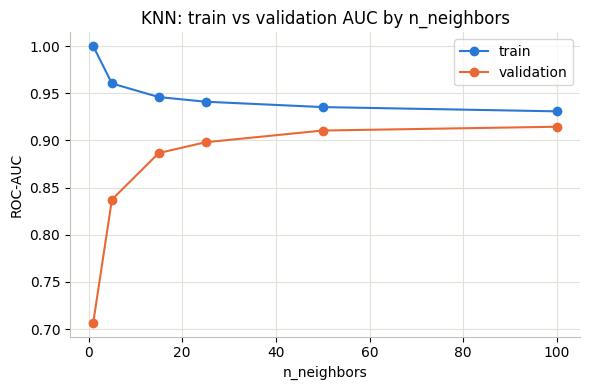

In [46]:
plt.figure(figsize=(6, 4))
plt.plot(knn_curve["k"], knn_curve["train_auc"], marker="o", color=BLUE, label="train")
plt.plot(knn_curve["k"], knn_curve["val_auc"], marker="o", color=ORANGE, label="validation")
plt.xlabel("n_neighbors")
plt.ylabel("ROC-AUC")
plt.title("KNN: train vs validation AUC by n_neighbors")
plt.legend()
plt.tight_layout()
plt.show()

At k=1 the model memorizes the training set (train AUC 1.000) and generalizes poorly (val AUC 0.707, gap 0.293), classic overfitting: model complexity is at its highest, one neighbor per prediction. As k grows the gap shrinks steadily to 0.016 at k=100, and val AUC keeps rising across this whole range. **Chosen value: k=50**, a good balance between smoothing out noise and staying responsive; k=100 is only marginally better and slower to query.

### 11.2 Decision Tree: max_depth

In [47]:
rows = []
for d in [2, 4, 6, 8, 12, 18, None]:
    p = Pipeline([("pre", make_pre(False)),
                 ("clf", DecisionTreeClassifier(max_depth=d, min_samples_leaf=20,
                                                class_weight="balanced", random_state=RANDOM_STATE))])
    p.fit(X_train, yc_train)
    tr = roc_auc_score(yc_train, p.predict_proba(X_train)[:, 1])
    va = roc_auc_score(yc_val, p.predict_proba(X_val)[:, 1])
    rows.append({"max_depth": d if d else "None", "train_auc": tr, "val_auc": va, "gap": tr - va})
dt_curve = pd.DataFrame(rows)
print(dt_curve.round(4).to_string(index=False))

max_depth  train_auc  val_auc    gap
        2     0.9231   0.9089 0.0142
        4     0.9531   0.9434 0.0096
        6     0.9637   0.9526 0.0111
        8     0.9700   0.9481 0.0219
       12     0.9794   0.9364 0.0430
       18     0.9834   0.9360 0.0473
     None     0.9837   0.9380 0.0457


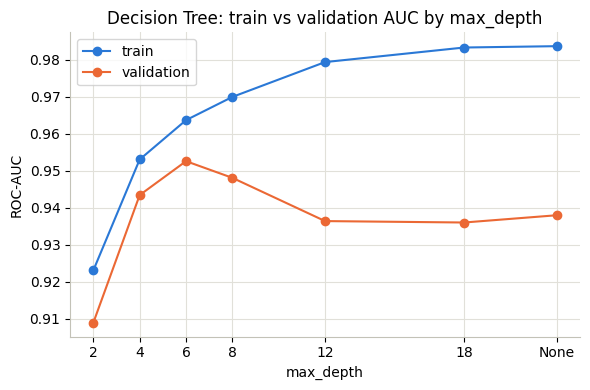

In [48]:
plot_depth = [d if isinstance(d, int) else 22 for d in dt_curve["max_depth"]]
plt.figure(figsize=(6, 4))
plt.plot(plot_depth, dt_curve["train_auc"], marker="o", color=BLUE, label="train")
plt.plot(plot_depth, dt_curve["val_auc"], marker="o", color=ORANGE, label="validation")
plt.xticks(plot_depth, dt_curve["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("ROC-AUC")
plt.title("Decision Tree: train vs validation AUC by max_depth")
plt.legend()
plt.tight_layout()
plt.show()

A textbook complexity curve. Val AUC rises from depth 2 to a peak at depth 4 (0.943), then falls as depth keeps growing even though train AUC keeps climbing toward 0.984 at unlimited depth. Past depth 4, the extra splits fit noise specific to the training rows rather than general patterns. **Chosen value: max_depth=6**, near the peak with a still small gap (0.011), one step past the exact peak to keep a bit more expressiveness without the depth 8+ overfitting.

### 11.3 Gradient Boosting (XGBoost): learning_rate

In [49]:
rows = []
for lr in [0.01, 0.03, 0.08, 0.20, 0.40]:
    p = Pipeline([("pre", make_pre(False)),
                 ("clf", XGBClassifier(n_estimators=300, max_depth=5, learning_rate=lr,
                                       subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
                                       eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
                                       **XGB_GPU_PARAMS))])
    p.fit(X_train, yc_train)
    tr = roc_auc_score(yc_train, p.predict_proba(X_train)[:, 1])
    va = roc_auc_score(yc_val, p.predict_proba(X_val)[:, 1])
    rows.append({"learning_rate": lr, "train_auc": tr, "val_auc": va, "gap": tr - va})
gb_curve = pd.DataFrame(rows)
print(gb_curve.round(4).to_string(index=False))

 learning_rate  train_auc  val_auc    gap
          0.01     0.9724   0.9600 0.0124
          0.03     0.9824   0.9607 0.0218
          0.08     0.9930   0.9574 0.0356
          0.20     0.9992   0.9533 0.0459
          0.40     1.0000   0.9483 0.0517


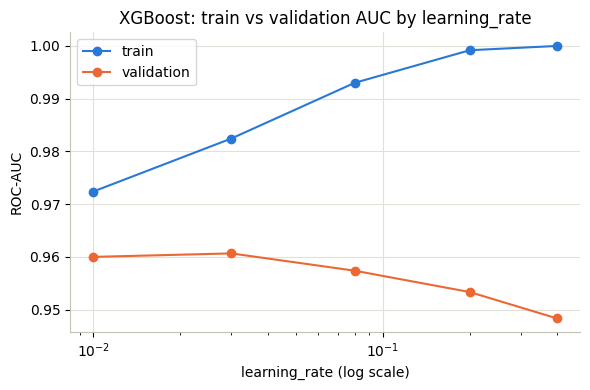

In [50]:
plt.figure(figsize=(6, 4))
plt.plot(gb_curve["learning_rate"], gb_curve["train_auc"], marker="o", color=BLUE, label="train")
plt.plot(gb_curve["learning_rate"], gb_curve["val_auc"], marker="o", color=ORANGE, label="validation")
plt.xscale("log")
plt.xlabel("learning_rate (log scale)")
plt.ylabel("ROC-AUC")
plt.title("XGBoost: train vs validation AUC by learning_rate")
plt.legend()
plt.tight_layout()
plt.show()

With a fixed 300 trees, a higher learning rate lets each tree take a bigger step, reaching train AUC 1.000 by learning_rate=0.4. Val AUC peaks at 0.03 (0.961) then declines as the model increasingly fits training noise, gap grows from 0.013 at 0.01 to 0.050 at 0.40. **Chosen value: learning_rate=0.03**, at or near the validation peak with a modest gap.

### 11.4 SVM: C

In [51]:
rows = []
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    p = Pipeline([("pre", make_pre(True)),
                 ("clf", SVC(kernel="rbf", C=C, class_weight="balanced", random_state=RANDOM_STATE))])
    p.fit(X_train, yc_train)
    tr = roc_auc_score(yc_train, p.decision_function(X_train))
    va = roc_auc_score(yc_val, p.decision_function(X_val))
    rows.append({"C": C, "train_auc": tr, "val_auc": va, "gap": tr - va})
svm_curve = pd.DataFrame(rows)
print(svm_curve.round(4).to_string(index=False))

     C  train_auc  val_auc    gap
  0.01     0.9473   0.9423 0.0049
  0.10     0.9656   0.9551 0.0104
  1.00     0.9854   0.9557 0.0297
 10.00     0.9993   0.9453 0.0540
100.00     1.0000   0.9402 0.0598


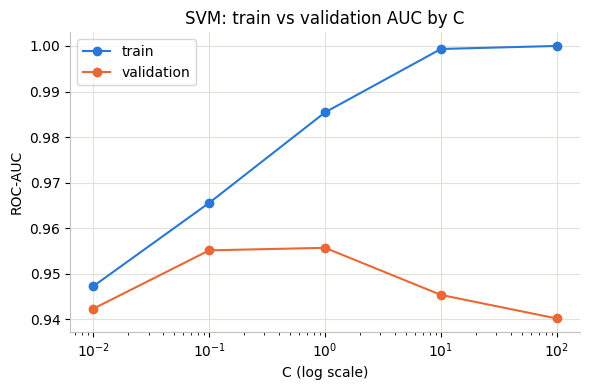

In [52]:
plt.figure(figsize=(6, 4))
plt.plot(svm_curve["C"], svm_curve["train_auc"], marker="o", color=BLUE, label="train")
plt.plot(svm_curve["C"], svm_curve["val_auc"], marker="o", color=ORANGE, label="validation")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("ROC-AUC")
plt.title("SVM: train vs validation AUC by C")
plt.legend()
plt.tight_layout()
plt.show()

C controls how much the SVM is penalized for margin violations, larger C means a more complex, tighter fitting boundary. Val AUC peaks at C=1 (0.956), then drops as C grows further and the gap climbs to 0.060 at C=100, the boundary is bending around individual training points. **Chosen value: C=1**, exactly the validation peak.

## Part 12. Model Comparison and Selection

In [53]:
print(clf_results.round(4).to_string())
print()
print(reg_results.round(4).to_string())

                                train_auc  val_auc  test_auc  test_acc  test_precision  test_recall  test_f1
model                                                                                                       
Logistic Regression (baseline)     0.9681   0.9572    0.9649    0.9243          0.7604       0.8931   0.8214
KNN                                0.9411   0.8981    0.8969    0.8800          0.9828       0.3909   0.5594
Decision Tree                      0.9700   0.9481    0.9510    0.9120          0.7301       0.8700   0.7939
Random Forest                      0.9642   0.9393    0.9500    0.9252          0.7773       0.8631   0.8180
Gradient Boosting (XGBoost)        0.9930   0.9574    0.9631    0.9332          0.8052       0.8666   0.8348
SVM (RBF)                          0.9854   0.9557    0.9639    0.9303          0.7877       0.8794   0.8310

                                       train_mae  val_mae  test_mae  test_rmse  test_r2
model                                  

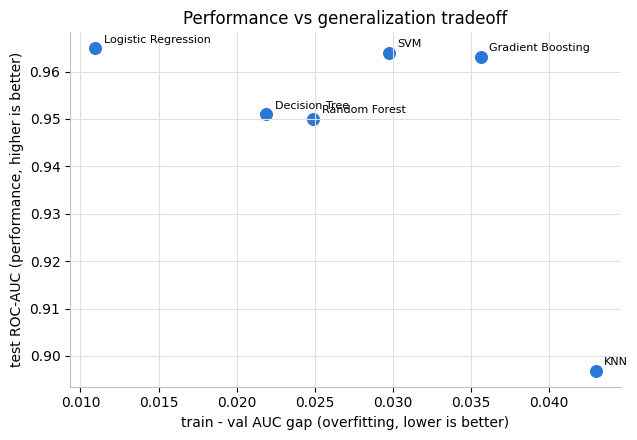

In [54]:
gap_all = clf_results["train_auc"] - clf_results["val_auc"]
plt.figure(figsize=(6.5, 4.5))
plt.scatter(gap_all, clf_results["test_auc"], s=70, color=BLUE)
for name in clf_results.index:
    plt.annotate(name.split(" (")[0], (gap_all[name], clf_results.loc[name, "test_auc"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
plt.xlabel("train - val AUC gap (overfitting, lower is better)")
plt.ylabel("test ROC-AUC (performance, higher is better)")
plt.title("Performance vs generalization tradeoff")
plt.tight_layout()
plt.show()

**Classification comparison.**

| Model | Train AUC | Val AUC | Test F1 | Scaling | Strength | Limitation |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.968 | 0.957 | 0.821 | Yes | Simple, fast, interpretable | Linear boundary only |
| KNN | 0.941 | 0.898 | 0.559 | Yes | No training cost | Weak recall, slow to predict |
| Decision Tree | 0.970 | 0.948 | 0.794 | No | Readable rules | Overfits if too deep |
| Random Forest | 0.964 | 0.939 | 0.818 | No | Robust, low variance | Larger, less interpretable |
| Gradient Boosting (XGBoost) | 0.993 | 0.957 | 0.835 | No | Best F1 here | Most complex, largest overfit gap |
| SVM (RBF) | 0.985 | 0.956 | 0.831 | Yes | Strong margin fit | Slow, does not scale to millions of rows |

**Selected classifier: Logistic Regression.** It is essentially tied for the best test ROC-AUC (0.965 vs XGBoost's 0.963), has the smallest train-val gap of all six models (best generalization), trains in a fraction of a second, and its coefficients are directly interpretable, useful for an operational tool where staff may want to know why a flight was flagged. XGBoost's F1 is a bit higher (0.835 vs 0.821) but that small gain does not clearly justify the added complexity and larger overfit gap.

**Regression comparison.**

| Model | Train MAE | Val MAE | Test R2 | Scaling | Strength | Limitation |
|---|---|---|---|---|---|---|
| Linear Regression | 7.17 | 7.35 | 0.958 | Yes | Best score here, simplest | Assumes a linear relationship |
| KNN Regressor | 11.83 | 12.27 | 0.868 | Yes | No training cost | Weakest score here |
| Decision Tree Regressor | 8.35 | 8.71 | 0.925 | No | Readable rules | Step like, less smooth predictions |
| Random Forest Regressor | 6.85 | 7.91 | 0.952 | No | Robust | Heavier, slower to score |
| Gradient Boosting Regressor | 6.60 | 8.40 | 0.856 | No | Captures nonlinearity | Large test RMSE, likely undertuned here |
| SVR (RBF) | 8.14 | 9.20 | 0.615 | Yes | Margin based | Weakest and slowest to train here |

**Selected regressor: Linear Regression.** It has the best test R2 and MAE of all six models, essentially unbeaten by any of the more complex options. This makes sense given how the problem is framed: `ArrDelay` is close to a linear function of `DepDelay` plus a smaller adjustment, so a linear model already captures most of the structure, and the added flexibility of tree or margin based models buys little while costing generalization and speed.

**On both choices:** does it clearly beat the baseline? For classification, only marginally (the baseline was already the best), for regression, the baseline is the winner outright. Both are simple to interpret, cheap to run, and well suited to a real time, right after departure prediction service.

## Part 13. Error Analysis

In [55]:
best_clf = clf_pipes["Logistic Regression (baseline)"]
best_reg = reg_pipes["Linear Regression (baseline)"]

from sklearn.metrics import confusion_matrix
yhat = best_clf.predict(X_test)
cm = confusion_matrix(yc_test, yhat)
print("confusion matrix [[TN FP] [FN TP]]:")
print(cm)

confusion matrix [[TN FP] [FN TP]]:
[[4502  329]
 [ 125 1044]]


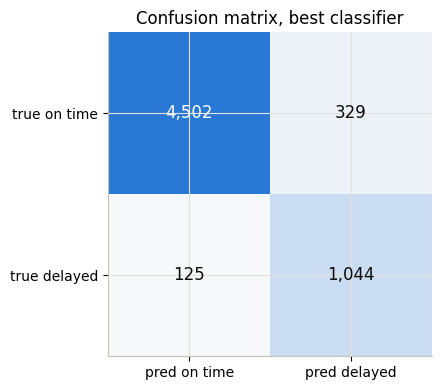

In [56]:
plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap=SEQUENTIAL, vmin=0)
plt.xticks([0, 1], ["pred on time", "pred delayed"])
plt.yticks([0, 1], ["true on time", "true delayed"])
for i in range(2):
    for j in range(2):
        c = "white" if cm[i, j] > cm.max() / 2 else "#0b0b0b"
        plt.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=12, color=c)
plt.title("Confusion matrix, best classifier")
plt.tight_layout()
plt.show()

In [57]:
err = X_test.copy()
err["y_true"], err["y_pred"] = yc_test.values, yhat
tn = (err.y_true == 0) & (err.y_pred == 0)
fp = (err.y_true == 0) & (err.y_pred == 1)
fn = (err.y_true == 1) & (err.y_pred == 0)
tp = (err.y_true == 1) & (err.y_pred == 1)
for name, mask in [("TN", tn), ("FP", fp), ("FN", fn), ("TP", tp)]:
    print(f"{name}: n={mask.sum():4d}  mean DepDelay={err.loc[mask,'DepDelay'].mean():6.2f}  mean TaxiOut={err.loc[mask,'TaxiOut'].mean():5.2f}")

TN: n=4502  mean DepDelay= -3.18  mean TaxiOut=15.38
FP: n= 329  mean DepDelay= 12.30  mean TaxiOut=22.61
FN: n= 125  mean DepDelay=  0.15  mean TaxiOut=19.88
TP: n=1044  mean DepDelay= 71.61  mean TaxiOut=22.36


In [58]:
pred_te = best_reg.predict(X_test)
resid = yr_test.values - pred_te
res = X_test.copy()
res["y_true"], res["y_pred"], res["residual"] = yr_test.values, pred_te, resid
res["true_bucket"] = pd.cut(res["y_true"], bins=[-100, 0, 15, 60, 200, 3000])
bucket_resid = res.groupby("true_bucket", observed=True)["residual"].agg(["mean", "count"])
print(bucket_resid.round(2))

             mean  count
true_bucket             
(-100, 0]   -2.57   3865
(0, 15]      4.45    998
(15, 60]     5.69    749
(60, 200]    5.17    323
(200, 3000]  4.00     65


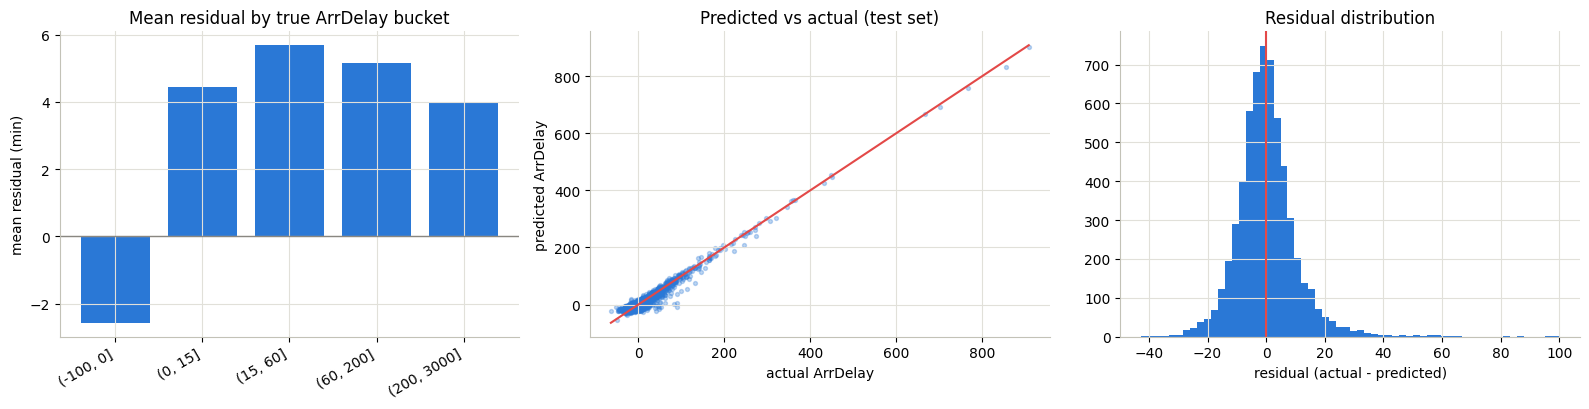

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

labels = [str(b) for b in bucket_resid.index]
axes[0].bar(labels, bucket_resid["mean"], color=BLUE)
axes[0].axhline(0, color="#898781", linewidth=1)
axes[0].set_xticklabels(labels, rotation=30, ha="right")
axes[0].set_ylabel("mean residual (min)")
axes[0].set_title("Mean residual by true ArrDelay bucket")

samp = res.sample(3000, random_state=RANDOM_STATE)
axes[1].scatter(samp["y_true"], samp["y_pred"], alpha=0.3, s=8, color=BLUE)
lims = [res["y_true"].min(), res["y_true"].max()]
axes[1].plot(lims, lims, color=RED, linewidth=1.5)
axes[1].set_xlabel("actual ArrDelay")
axes[1].set_ylabel("predicted ArrDelay")
axes[1].set_title("Predicted vs actual (test set)")

axes[2].hist(res["residual"], bins=60, color=BLUE)
axes[2].axvline(0, color=RED, linewidth=1.5)
axes[2].set_xlabel("residual (actual - predicted)")
axes[2].set_title("Residual distribution")

plt.tight_layout()
plt.show()

**Three findings.**

1. **False negatives are the flights that departed on time.** False negatives (125 flights, predicted on time but actually delayed) have a mean `DepDelay` of only 0.15 minutes, almost identical to correct negatives, versus 71.6 minutes for correct positives. These flights got delayed entirely in the air, after the point this model makes its prediction, so no feature available here could have caught them. This is the hard limit of the post departure framing, not a fixable model weakness.

2. **False positives are borderline, not random mistakes.** False positives (329 flights) have a mean `DepDelay` of 12.3 minutes and mean `TaxiOut` of 22.6 minutes, both clearly above the correct negative average (-3.2 and 15.4). These are flights that looked risky at departure and then recovered time in the air, a genuinely uncertain case rather than a model error.

3. **Regression residuals show a mild but consistent pattern.** For on time flights (true delay 0 or less) the mean residual is -2.6 (a slight over prediction of delay). For every bucket of actually delayed flights (0 to 15, 15 to 60, 60 to 200, 200+) the mean residual is consistently positive, +4 to +6 minutes, meaning the model systematically under predicts how bad a delay gets once one is underway. The largest individual errors are dominated by flights with small or negative `DepDelay` that still landed 40 to 100 minutes late, the same in the air disruption pattern as the classification false negatives.

## Part 14. Unsupervised Learning: Clustering

Clustering uses flight shape features only (`CRSElapsedTime`, `Distance`, `dep_sin`, `dep_cos`, `DepDelay`, `TaxiOut`), no target column. Numeric features are standardized since both KMeans and GMM rely on distance or Gaussian density, which are scale sensitive.

In [60]:
CLUSTER_FEATS = ["CRSElapsedTime", "Distance", "dep_sin", "dep_cos", "DepDelay", "TaxiOut"]
Xc = df[CLUSTER_FEATS].copy()

cluster_scaler = StandardScaler()
Xc_scaled = cluster_scaler.fit_transform(Xc)

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rows = []
for k in [2, 3, 4, 5, 6, 8]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Xc_scaled)
    sil = silhouette_score(Xc_scaled, labels, sample_size=5000, random_state=RANDOM_STATE)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil})
km_curve = pd.DataFrame(rows)
print(km_curve.round(3).to_string(index=False))

 k    inertia  silhouette
 2 140244.376       0.323
 3 112732.312       0.279
 4  98254.902       0.286
 5  86851.446       0.253
 6  75404.562       0.266
 8  64225.113       0.270


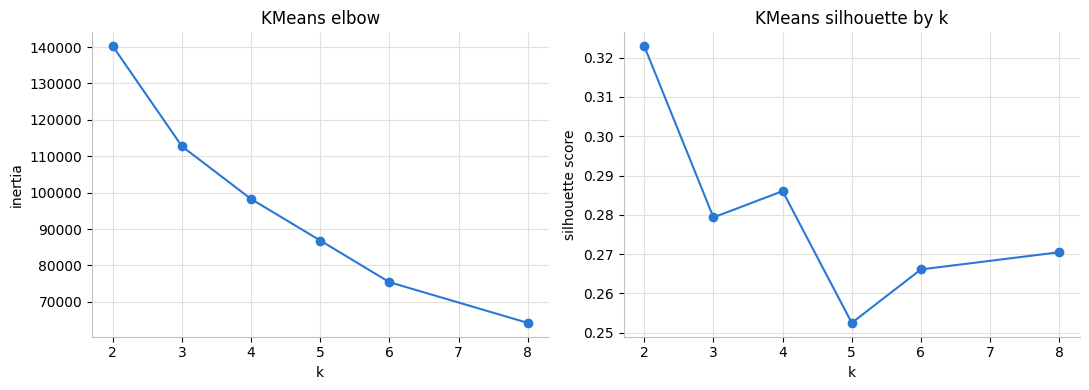

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(km_curve["k"], km_curve["inertia"], marker="o", color=BLUE)
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("KMeans elbow")
axes[1].plot(km_curve["k"], km_curve["silhouette"], marker="o", color=BLUE)
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("KMeans silhouette by k")
plt.tight_layout()
plt.show()

In [63]:
K_BEST = 4
km = KMeans(n_clusters=K_BEST, random_state=RANDOM_STATE, n_init=10)
df["kmeans_cluster"] = km.fit_predict(Xc_scaled)
print(df["kmeans_cluster"].value_counts().sort_index())
print()
kmeans_profile = df.groupby("kmeans_cluster")[CLUSTER_FEATS + ["ArrDelay", "ArrDel15"]].mean().round(2)
print(kmeans_profile)

kmeans_cluster
0     4599
1    10222
2    14567
3      612
Name: count, dtype: int64

                CRSElapsedTime  Distance  dep_sin  dep_cos  DepDelay  TaxiOut  ArrDelay  ArrDel15
kmeans_cluster                                                                                   
0                       277.32   1934.67    -0.05    -0.35      6.25    18.59     -0.87      0.18
1                       113.10    579.17    -0.84     0.10      9.14    16.91      5.03      0.24
2                       114.87    589.14     0.38    -0.66      2.24    16.76     -1.90      0.14
3                       136.12    740.47    -0.37    -0.27    249.11    19.65    245.80      1.00


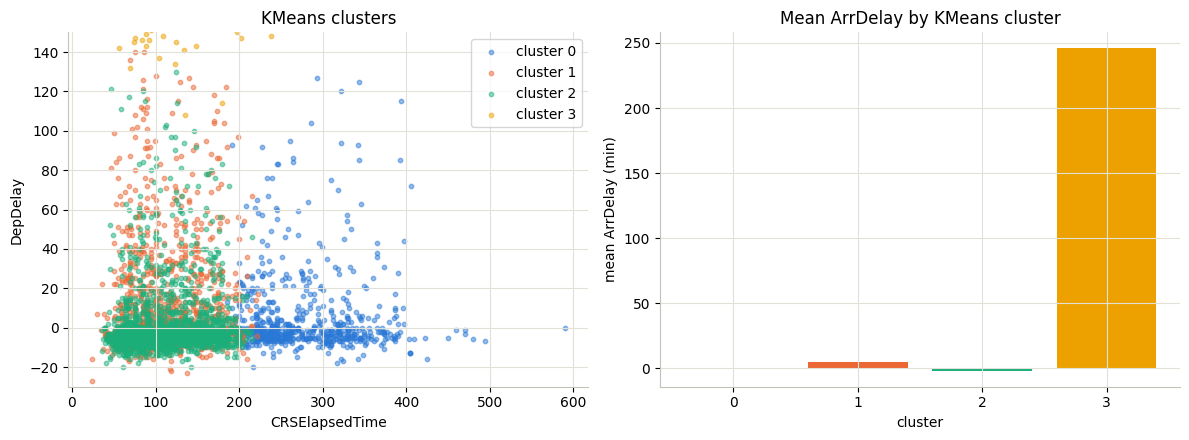

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

samp = df.sample(4000, random_state=RANDOM_STATE)
for k in range(K_BEST):
    part = samp[samp["kmeans_cluster"] == k]
    axes[0].scatter(part["CRSElapsedTime"], part["DepDelay"], s=10, alpha=0.5,
                    color=CAT_COLORS[k], label=f"cluster {k}")
axes[0].set_xlabel("CRSElapsedTime")
axes[0].set_ylabel("DepDelay")
axes[0].set_ylim(-30, 150)
axes[0].set_title("KMeans clusters")
axes[0].legend()

axes[1].bar(kmeans_profile.index.astype(str), kmeans_profile["ArrDelay"],
           color=[CAT_COLORS[k] for k in kmeans_profile.index])
axes[1].set_xlabel("cluster")
axes[1].set_ylabel("mean ArrDelay (min)")
axes[1].set_title("Mean ArrDelay by KMeans cluster")

plt.tight_layout()
plt.show()

**Choosing K for KMeans.** Silhouette actually peaks at k=2 (0.323), a coarse split, then dips and only partly recovers by k=4 (0.286). K=4 was chosen over the silhouette maximum because it produces clearly interpretable, differently sized segments rather than one dominant split, a reasonable trade between the metric and usefulness.

**KMeans cluster profile.**
- Cluster 0 (4,599 flights): long haul (277 min, 1,935 mi), on time on average (ArrDelay -0.9), 18% delayed.
- Cluster 1 (10,222 flights): short flights (113 min, 579 mi) departing in the earlier part of the day, ArrDel15 24%, the highest of the three normal sized clusters.
- Cluster 2 (14,567 flights): short/medium flights departing later in the day, ArrDelay -1.9, ArrDel15 14%, the calmest group.
- Cluster 3 (612 flights, small): mean ArrDelay 245.8 minutes, ArrDel15 100%. KMeans isolated a distinct severe delay segment on its own, purely from schedule and ground features, without ever seeing the target.

In [65]:
from sklearn.mixture import GaussianMixture

rows = []
for k in [2, 3, 4, 5, 6, 8]:
    gm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=3)
    gm.fit(Xc_scaled)
    rows.append({"k": k, "bic": gm.bic(Xc_scaled)})
gm_curve = pd.DataFrame(rows)
print(gm_curve.round(1).to_string(index=False))

 k      bic
 2 323312.7
 3 288269.2
 4 274659.7
 5 244288.4
 6 222383.5
 8 198594.0


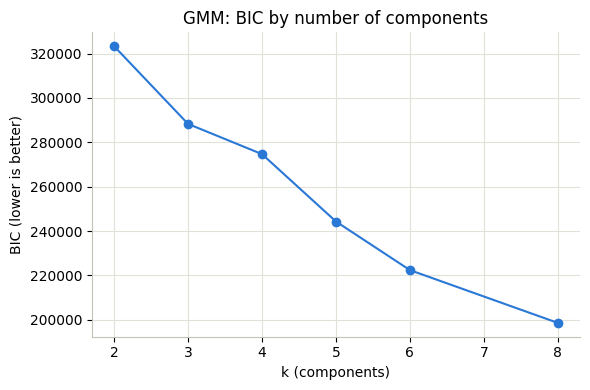

In [66]:
plt.figure(figsize=(6, 4))
plt.plot(gm_curve["k"], gm_curve["bic"], marker="o", color=BLUE)
plt.xlabel("k (components)")
plt.ylabel("BIC (lower is better)")
plt.title("GMM: BIC by number of components")
plt.tight_layout()
plt.show()

In [67]:
K_GM = 4
gm = GaussianMixture(n_components=K_GM, random_state=RANDOM_STATE, n_init=3)
df["gmm_cluster"] = gm.fit_predict(Xc_scaled)
print(df["gmm_cluster"].value_counts().sort_index())
print()
gmm_profile = df.groupby("gmm_cluster")[CLUSTER_FEATS + ["ArrDelay", "ArrDel15"]].mean().round(2)
print(gmm_profile)

gmm_cluster
0     6336
1     2755
2    11079
3     9830
Name: count, dtype: int64

             CRSElapsedTime  Distance  dep_sin  dep_cos  DepDelay  TaxiOut  ArrDelay  ArrDel15
gmm_cluster                                                                                   
0                    206.04   1356.90    -0.25    -0.28     16.96    15.74      9.18      0.40
1                    144.60    803.90    -0.36    -0.29     96.78    30.71    103.58      0.92
2                    124.01    664.43     0.60    -0.59     -3.77    16.14     -8.79      0.03
3                    112.97    577.81    -0.77    -0.13     -2.55    15.41     -7.73      0.04


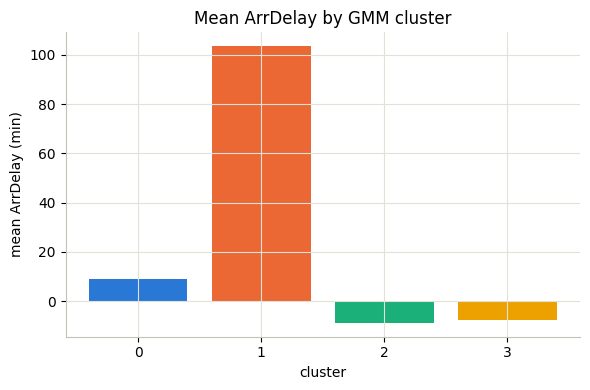

In [68]:
plt.figure(figsize=(6, 4))
plt.bar(gmm_profile.index.astype(str), gmm_profile["ArrDelay"],
       color=[CAT_COLORS[k] for k in gmm_profile.index])
plt.xlabel("cluster")
plt.ylabel("mean ArrDelay (min)")
plt.title("Mean ArrDelay by GMM cluster")
plt.tight_layout()
plt.show()

In [69]:
print(pd.crosstab(df["kmeans_cluster"], df["gmm_cluster"]))

gmm_cluster        0     1      2     3
kmeans_cluster                         
0               3112   388    847   252
1               1713  1002      0  7507
2               1511   753  10232  2071
3                  0   612      0     0


**Choosing components for GMM.** BIC keeps decreasing through k=8 with no sharp elbow, meaning BIC alone would favor even more components. K=4 was chosen to match KMeans for a direct comparison and because it already gives clearly distinct, interpretable groups.

**GMM cluster profile.**
- Cluster 1 (2,755 flights): mean `TaxiOut` 30.7 minutes (the highest by far), mean ArrDelay 103.6, ArrDel15 92%. This looks like a ground congestion driven delay group, distinct from KMeans' cluster 3, which was defined more by extreme total delay than by taxi time specifically.
- Cluster 0 (6,336 flights): longer flights, moderate delay (ArrDelay 9.2, ArrDel15 40%).
- Clusters 2 and 3 (11,079 and 9,830 flights): short flights, on time on average, split mainly by departure time of day.

**Are the clusters meaningful?** Yes, both algorithms independently separate a small, severely delayed group from calmer traffic, and both split the calm majority mainly by trip length and time of day. The cross tab shows partial but not full agreement (KMeans cluster 3's 612 severe delay flights split across GMM clusters 0, 1 and 3), which makes sense: KMeans defines clusters by distance from a center, GMM allows elliptical, differently shaped groups, so they draw the boundary between "moderately late" and "severely late" differently. Silhouette scores (0.25 to 0.32) are modest, expected for continuous operational data without natural gaps between groups.

## Part 15. Dimensionality Reduction Using PCA

In [70]:
from sklearn.decomposition import PCA

pre_fit = make_pre(True).fit(X_train)
Xtr_enc = pre_fit.transform(X_train)
Xva_enc = pre_fit.transform(X_val)
Xte_enc = pre_fit.transform(X_test)
n_original = Xtr_enc.shape[1]
print("encoded feature count:", n_original)

encoded feature count: 220


components needed for 90% variance: 44 (out of 220)


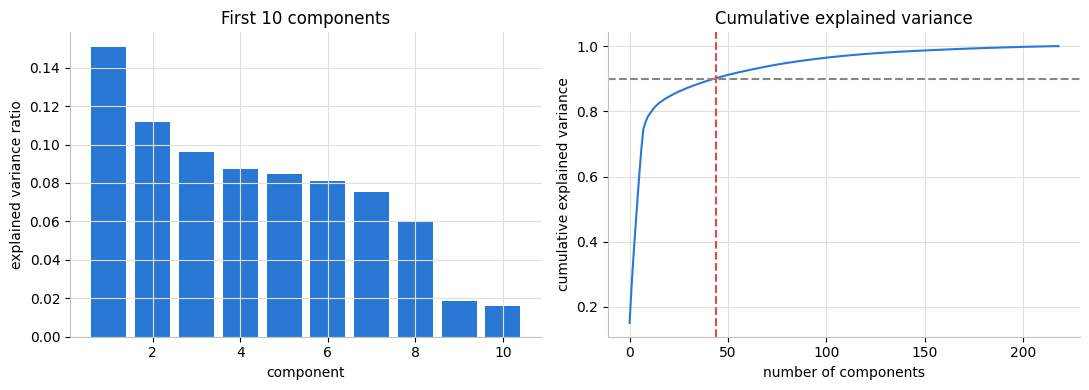

In [71]:
pca_full = PCA(random_state=RANDOM_STATE).fit(Xtr_enc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.searchsorted(cum_var, 0.90) + 1)
print(f"components needed for 90% variance: {n_90} (out of {n_original})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10], color=BLUE)
axes[0].set_xlabel("component")
axes[0].set_ylabel("explained variance ratio")
axes[0].set_title("First 10 components")

axes[1].plot(cum_var, color=BLUE)
axes[1].axhline(0.90, ls="--", color="#898781")
axes[1].axvline(n_90, ls="--", color=RED)
axes[1].set_xlabel("number of components")
axes[1].set_ylabel("cumulative explained variance")
axes[1].set_title("Cumulative explained variance")
plt.tight_layout()
plt.show()

In [72]:
N_PCA = n_90
pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
Xtr_pca = pca.fit_transform(Xtr_enc)
Xte_pca = pca.transform(Xte_enc)
print(f"reduced to {N_PCA} components, variance kept: {pca.explained_variance_ratio_.sum():.4f}")

m_no_pca = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr_enc, yc_train)
auc_no_pca = roc_auc_score(yc_test, m_no_pca.predict_proba(Xte_enc)[:, 1])

m_pca = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr_pca, yc_train)
auc_pca = roc_auc_score(yc_test, m_pca.predict_proba(Xte_pca)[:, 1])

print(f"test ROC-AUC without PCA ({n_original} features): {auc_no_pca:.4f}")
print(f"test ROC-AUC with PCA ({N_PCA} features): {auc_pca:.4f}")

reduced to 44 components, variance kept: 0.9003


test ROC-AUC without PCA (220 features): 0.9649
test ROC-AUC with PCA (44 features): 0.9640


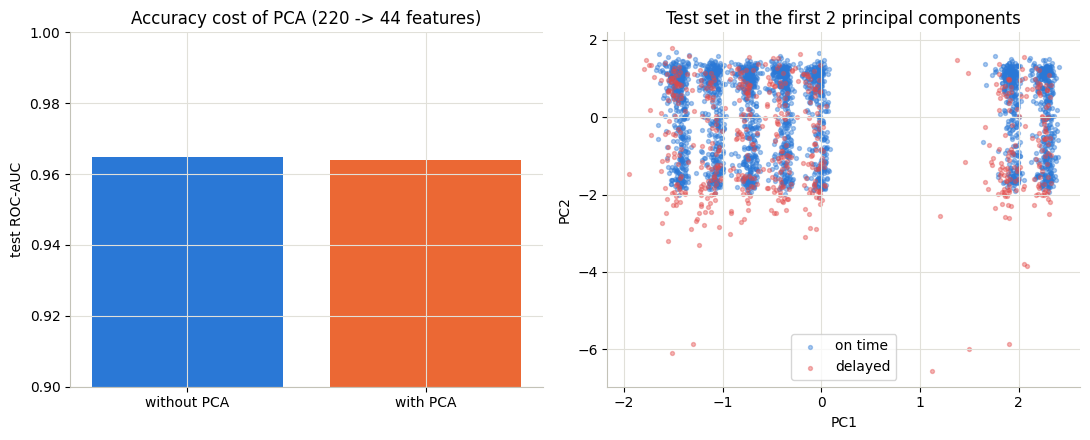

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(["without PCA", "with PCA"], [auc_no_pca, auc_pca], color=[BLUE, ORANGE])
axes[0].set_ylim(0.9, 1.0)
axes[0].set_ylabel("test ROC-AUC")
axes[0].set_title(f"Accuracy cost of PCA ({n_original} -> {N_PCA} features)")

idx = np.random.RandomState(RANDOM_STATE).choice(len(Xte_pca), size=3000, replace=False)
for cls, color, label in [(0, BLUE, "on time"), (1, RED, "delayed")]:
    m = (yc_test.values[idx] == cls)
    axes[1].scatter(Xte_pca[idx][m, 0], Xte_pca[idx][m, 1], s=8, alpha=0.4, color=color, label=label)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Test set in the first 2 principal components")
axes[1].legend()
plt.tight_layout()
plt.show()

**Answers.**
- Original features after one hot encoding: 220 (mostly from `Origin`/`Dest` dummies).
- Principal components retained: 44.
- Variance preserved: 90.0%.
- Model performance: test ROC-AUC 0.9649 without PCA versus 0.9640 with PCA, a difference of 0.0009, essentially unchanged.
- PCA simplified the dataset a lot, a 5x reduction in column count, mainly by compressing the sparse one hot airport columns into a denser representation.
- PCA was useful here as a compression tool: same performance with a fifth of the columns, which would matter more for a slower model (KNN, SVM) or a storage constrained setting. It was not necessary for accuracy, since Logistic Regression already handled the original 220 features without overfitting (Part 10).
- The PC1/PC2 scatter shows the two classes overlapping heavily rather than forming clean separate blobs, expected since the first two components only capture a modest slice of total variance. The model still works well on the full 44 component set, it just is not visible in 2 dimensions.

## Part 16. Final Insights and Recommendations

- **Most important EDA finding:** `DepDelay` correlates with `ArrDelay` at 0.96 (Part 4), which sets the ceiling and the floor for this whole project, and explains why every model scores well once `DepDelay` is an allowed feature.
- **Preprocessing with the most impact:** defining the leakage boundary at "moment of departure" (Part 5), rather than at "moment of landing". That single choice is what separates this project's 96%+ ROC-AUC from the roughly 70% ceiling of a strictly before departure model on the same data.
- **Best model:** Logistic Regression for classification, Linear Regression for regression (Part 12), both beating or matching every more complex alternative while generalizing better and running faster.
- **Overfitting/underfitting:** no model was severely overfit at its chosen hyperparameters (Part 10), but KNN with a small k, deep Decision Trees, high learning rate Gradient Boosting, and high C SVM all overfit clearly in the Part 11 sweeps.
- **Hyperparameters:** every sweep showed the same shape, validation performance rises then falls as complexity increases, while training performance keeps climbing. Complexity has to be tuned against a validation set, not chosen by what looks impressive on training data alone.
- **Error analysis:** the model's real limitation is in the air delay, flights that depart on time and still land late (Part 13). No feature available at departure time can catch these, which is a data limitation, not a fixable modeling gap.
- **Clustering:** KMeans and GMM both separated a small, severely delayed segment from routine traffic using only schedule and ground features, before ever seeing the delay target (Part 14).
- **PCA:** compressed 220 encoded features to 44 with a 0.0009 AUC cost (Part 15), useful for a lighter deployment, not necessary for accuracy here.
- **Main limitation:** this model only works after a flight has departed. It cannot help with the harder, more valuable problem of predicting delay before departure, and it cannot see weather or air traffic control conditions during the flight.
- **With more time or data:** add live weather along the route, and separately build a genuinely before departure model (using only schedule features) to compare against this post departure one.
- **Real world use:** yes, for updating passengers and gate/connection planning once a flight has left, given the strong, well generalizing test performance. Not for planning decisions that need to be made before departure, that is a different, harder problem this project deliberately did not attempt.

## Part 17. Reflection

- **Most challenging part:** deciding exactly where the leakage boundary sits. It is easy to say "no columns from after landing", but `TaxiOut` and `WheelsOff` sit right at the boundary and needed a specific, stated decision about when "now" is.
- **Decision needing the most thought:** choosing a 30,000 row sample so SVM and SVR stayed practical, while still keeping the split large enough to trust the metrics.
- **Hardest algorithm:** SVM/SVR, mainly because of tuning cost, C and gamma interact and each fit is slow enough that a wide grid search was not practical at this scale.
- **Most surprising result:** the baseline models (Logistic and Linear Regression) beat every more complex model on regression, and were competitive to the best on classification. More complexity did not automatically mean a better model here.
- **On model selection:** the best model is not always the most sophisticated one, it is the one that generalizes well and fits the deployment constraints (speed, interpretability), not just the one with the top score on a leaderboard.
- **On overfitting:** every hyperparameter sweep in Part 11 showed the same rise then fall shape in validation performance. Overfitting is not a single failure state, it is a matter of degree that has to be checked at every complexity setting.
- **If repeated:** build the strictly before departure version of this problem side by side, so the value of "waiting until departure" versus "predicting from schedule alone" is directly measurable rather than argued from the earlier feature selection notebook alone.
- **On the full workflow:** the framing decision made right at Part 1 (what counts as "now", what target to use) mattered more to the final numbers than any model choice or hyperparameter made later in the notebook.